In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [2]:
df = pd.read_csv("output.csv")

In [3]:
df.columns

Index(['Unnamed: 0', 'Marital_status', 'Application_mode', 'Application_order',
       'Course', 'Daytime_evening_attendance', 'Previous_qualification',
       'Nacionality', 'Mothers_qualification', 'Fathers_qualification',
       'Mothers_occupation', 'Fathers_occupation', 'Displaced',
       'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date',
       'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International',
       'Curricular_units_1st_sem_credited',
       'Curricular_units_1st_sem_enrolled',
       'Curricular_units_1st_sem_evaluations',
       'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
       'Curricular_units_1st_sem_without_evaluations',
       'Curricular_units_2nd_sem_credited',
       'Curricular_units_2nd_sem_enrolled',
       'Curricular_units_2nd_sem_evaluations',
       'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
       'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate',
    

In [4]:
df = df.drop(columns=["Unnamed: 0"])

In [5]:
le = LabelEncoder()
df["Target_encoded"] = le.fit_transform(df["Target"])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}


In [6]:
df

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,...,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Target,Target_encoded
0,1.0,8.000000,5.00000,2.000000,1.0,1.0,1.000000,13.0,10.0,6.000000,...,0.271336,0.000000,0.00,0.000000,0.000000,0.459776,0.488889,0.766182,Dropout,0
1,1.0,1.000000,5.00000,5.000000,1.0,1.0,1.000000,22.0,27.0,10.000000,...,0.260870,0.000000,0.00,0.000000,0.000000,0.372093,0.488889,0.766182,Dropout,0
2,1.0,8.000000,2.00000,15.000000,1.0,1.0,1.000000,23.0,27.0,6.000000,...,0.260870,0.303030,0.25,0.667692,0.000000,0.209302,0.000000,0.536240,Graduate,2
3,2.0,12.000000,1.72214,3.000000,0.0,1.0,1.000000,22.0,28.0,10.000000,...,0.260870,0.181818,0.30,0.550720,0.000000,0.732558,0.111111,0.640687,Graduate,2
4,2.0,12.000000,1.00000,17.000000,0.0,12.0,1.000000,22.0,27.0,7.332924,...,0.217391,0.515152,0.25,0.619231,0.012079,1.000000,0.244444,0.414795,Graduate,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3962,1.0,1.000000,6.00000,15.000000,1.0,1.0,1.232363,1.0,1.0,6.000000,...,0.260870,0.242424,0.25,0.682051,0.000000,0.918605,0.800000,0.000000,Graduate,2
3963,1.0,6.925098,2.00000,15.000000,1.0,1.0,19.000000,1.0,1.0,10.000000,...,0.260870,0.244653,0.10,0.550720,0.000000,0.406977,0.311111,0.803170,Dropout,0
3964,1.0,1.000000,1.00000,12.000000,1.0,1.0,1.000000,22.0,27.0,10.000000,...,0.347826,0.244653,0.05,0.726923,0.000000,0.732558,0.449027,0.640687,Dropout,0
3965,1.0,1.000000,1.00000,9.910415,1.0,1.0,1.000000,22.0,27.0,8.000000,...,0.217391,0.181818,0.25,0.646154,0.000000,0.209302,0.000000,0.124174,Graduate,2


In [7]:
X = df.drop(columns=["Target", "Target_encoded"])
y = df["Target_encoded"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3173, 34)
Test shape: (794, 34)


In [9]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.654911838790932

Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.72      0.71       258
           1       0.29      0.28      0.29       142
           2       0.76      0.75      0.75       394

    accuracy                           0.65       794
   macro avg       0.58      0.58      0.58       794
weighted avg       0.65      0.65      0.65       794



In [10]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7355163727959698

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.75      0.78       258
           1       0.47      0.20      0.28       142
           2       0.74      0.92      0.82       394

    accuracy                           0.74       794
   macro avg       0.67      0.62      0.62       794
weighted avg       0.71      0.74      0.71       794



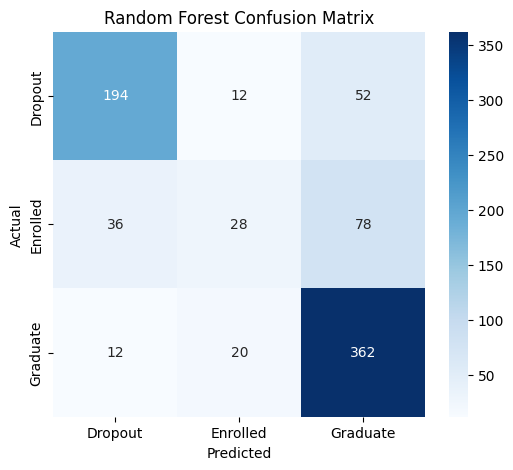

In [11]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

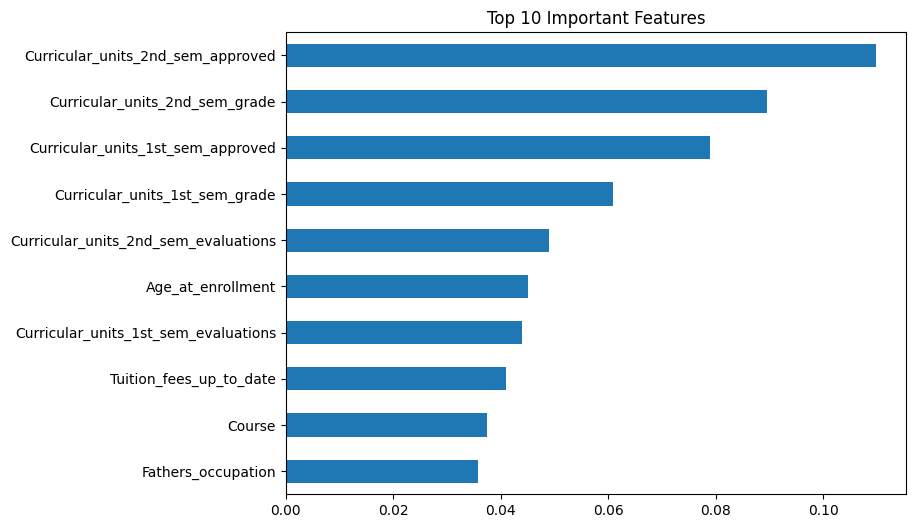

In [12]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,6))
importance.head(10).plot(kind="barh")
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

In [13]:
scores = cross_val_score(rf, X, y, cv=10)

print("Cross-validation accuracy:", scores.mean())

Cross-validation accuracy: 0.7506888787115487
